In [20]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from matplotlib import pyplot as plt
import seaborn as sns
import random
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import cross_val_score

In [21]:
df = pd.read_csv('supply_chain.csv')

# just want to summarize the dataset
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Shipment_ID                5000 non-null   str    
 1   Date                       5000 non-null   str    
 2   Origin_Port                5000 non-null   str    
 3   Destination_Port           5000 non-null   str    
 4   Transport_Mode             5000 non-null   str    
 5   Product_Category           5000 non-null   str    
 6   Distance_km                5000 non-null   float64
 7   Weight_MT                  5000 non-null   float64
 8   Fuel_Price_Index           5000 non-null   float64
 9   Geopolitical_Risk_Score    5000 non-null   float64
 10  Weather_Condition          5000 non-null   str    
 11  Carrier_Reliability_Score  5000 non-null   float64
 12  Lead_Time_Days             5000 non-null   float64
 13  Disruption_Occurred        5000 non-null   int64  
dtypes: 

In [22]:
df.head()

,Shipment_ID,Date,Origin_Port,Destination_Port,Transport_Mode,Product_Category,Distance_km,Weight_MT,Fuel_Price_Index,Geopolitical_Risk_Score,Weather_Condition,Carrier_Reliability_Score,Lead_Time_Days,Disruption_Occurred
0,SC-10000,2025-10-16,Singapore,Los Angeles,Rail,Textiles,5930.83,197.42,2.43,5.0,Hurricane,0.865,41.39,1
1,SC-10001,2024-04-24,Singapore,Shanghai,Rail,Automotive,14285.36,237.24,2.30,7.5,Storm,0.592,40.92,1
2,SC-10002,2024-01-26,Rotterdam,Los Angeles,Rail,Perishables,11113.91,427.42,1.78,5.6,Rain,0.673,11.54,0
3,SC-10003,2024-10-08,Busan,Hamburg,Rail,Electronics,9180.55,170.66,3.20,0.8,Hurricane,0.832,53.13,1
4,SC-10004,2024-09-07,Busan,Singapore,Air,Perishables,2762.27,434.96,2.77,1.9,Fog,0.741,0.50,1


In [23]:
df.shape

(5000, 14)

# EDA

In [24]:
# any columns that I need to delete?
# yea date and shipment_id dont need allat.
cols_del = ['Shipment_ID', 'Date']
df2 = df.drop(columns=cols_del)

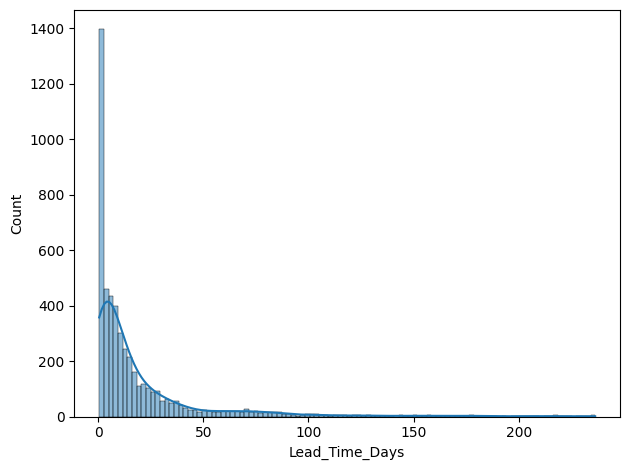

In [25]:
# Look at data wrangler every distribution looks good except for this:
sns.histplot(data=df2, x="Lead_Time_Days", kde=True)
plt.tight_layout()
plt.show()

# how can we fix this?

In [26]:
print(df2["Lead_Time_Days"].skew()) # just found out this was a thing!
# anyway, this is a right skew so I'm going to log transform
    # before scaling!
df2['Lead_Time_Days'] = np.log1p(df2['Lead_Time_Days'])


3.349222712647645


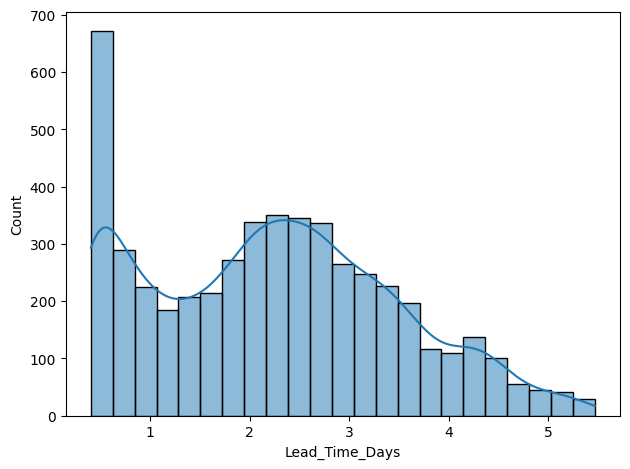

In [27]:
# now let's look at it
sns.histplot(data=df2, x="Lead_Time_Days", kde=True)
plt.tight_layout()
plt.show()

# much better!!

In [28]:
# everything else looks good
# I could get do some reduction in origin port and destination port, 
    # but it's only 8 and 9 distinct values I think it'll be okay

In [29]:
CATS = ["Origin_Port", "Destination_Port", "Transport_Mode",
    "Product_Category", "Weather_Condition"]

NUMERIC = ["Distance_km", "Weight_MT", "Fuel_Price_Index","Geopolitical_Risk_Score", 
           "Carrier_Reliability_Score", "Lead_Time_Days"]

# hot-encoding categorical features
df2 = pd.get_dummies(df2, columns=CATS, drop_first=True)

# minmax scaling numerical features
scaler = MinMaxScaler()
df2[NUMERIC] = scaler.fit_transform(df2[NUMERIC])


In [30]:
# splitting the data
X = df2.drop(columns='Disruption_Occurred')
y = df2['Disruption_Occurred']

In [31]:
prev = (df2['Disruption_Occurred'] == 1).sum() / len(df2['Disruption_Occurred'])
print(prev)

# 60/40 imbalance not too bad

0.6126


In [32]:
# split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Okay model time

In [33]:
neigh = KNeighborsClassifier(n_neighbors=5) # let's start w/ 5
neigh.fit(X_train, y_train) # fitting the model
neigh.score(X_test, y_test) # accuracy of the model

# wow that is terrible! 

0.654

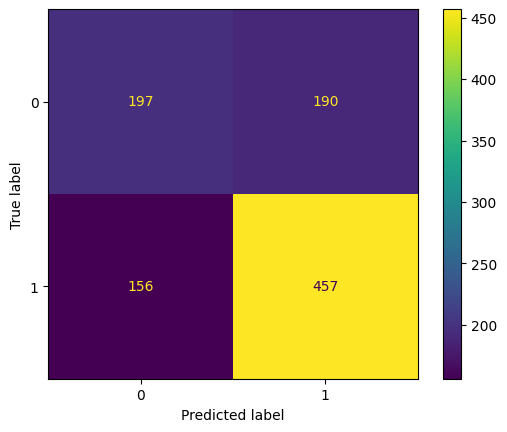

In [34]:
# let me look at the confusion matrix
ConfusionMatrixDisplay.from_estimator(neigh, X_test, y_test)
plt.show()

In [35]:
# Let me try adjusting k and 5-fold cv and see if that helps
for k in range(1, 21):
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train, y_train, cv=5)
    print(f"k={k}: {scores.mean():.3f}")

# Okay so cv didn't help much and neither did adjusting k.
    # this model is probably just some dooky for this

k=1: 0.634
k=2: 0.609
k=3: 0.649
k=4: 0.641
k=5: 0.655
k=6: 0.649
k=7: 0.658
k=8: 0.663
k=9: 0.667
k=10: 0.673
k=11: 0.676
k=12: 0.673
k=13: 0.677
k=14: 0.678
k=15: 0.676
k=16: 0.676
k=17: 0.672
k=18: 0.679
k=19: 0.672
k=20: 0.679


# Let's try a couple of more things

In [ ]:
# Weights parameter
neigh2 = KNeighborsClassifier(n_neighbors=5, weights='distance') # let's try weight=distance
    # this will weight closer neighbors more than farther neighbors
neigh2.fit(X_train, y_train)
neigh2.score(X_test, y_test)

# nope that didn't help.

0.657

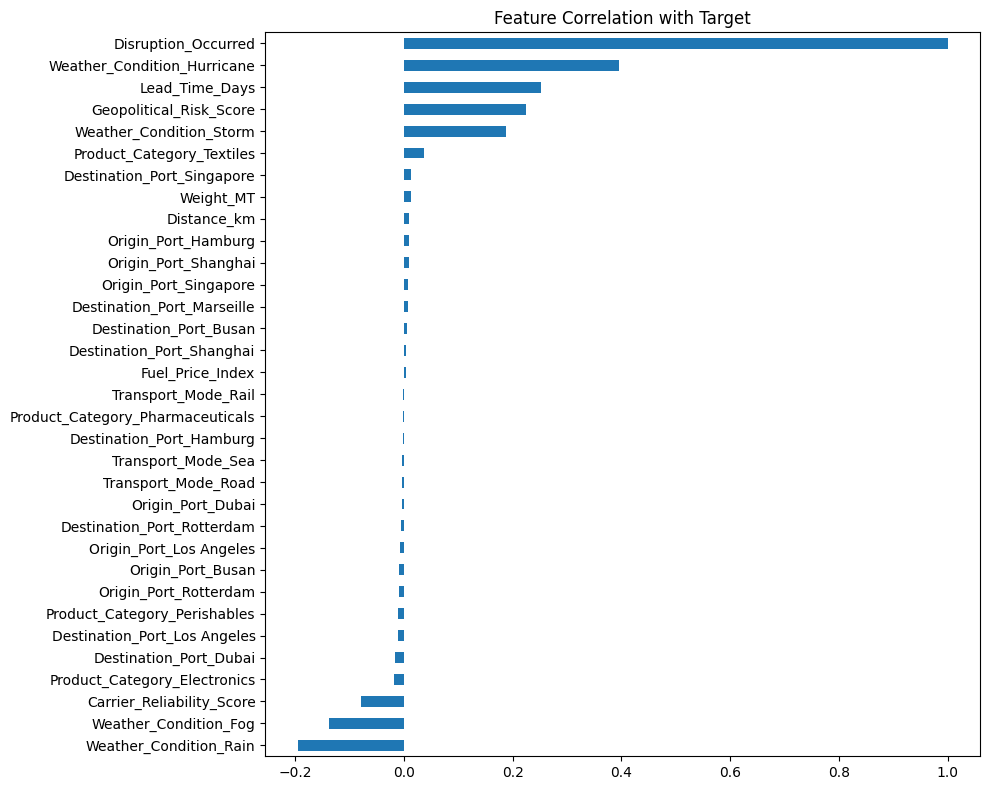

Weather_Condition_Rain             -0.195184
Weather_Condition_Fog              -0.138422
Carrier_Reliability_Score          -0.078927
Product_Category_Electronics       -0.017755
Destination_Port_Dubai             -0.016212
Destination_Port_Los Angeles       -0.010563
Product_Category_Perishables       -0.010345
Origin_Port_Rotterdam              -0.008249
Origin_Port_Busan                  -0.007974
Origin_Port_Los Angeles            -0.007298
Destination_Port_Rotterdam         -0.004678
Origin_Port_Dubai                  -0.003369
Transport_Mode_Road                -0.002582
Transport_Mode_Sea                 -0.002577
Destination_Port_Hamburg           -0.001796
Product_Category_Pharmaceuticals   -0.001306
Transport_Mode_Rail                -0.000899
Fuel_Price_Index                    0.003709
Destination_Port_Shanghai           0.004333
Destination_Port_Busan              0.006224
Destination_Port_Marseille          0.007489
Origin_Port_Singapore               0.007652
Origin_Por

In [40]:
# Feature selection?
df_corr = X.copy()
df_corr['Disruption_Occurred'] = y # have to combine these again

corr = df_corr.corr()['Disruption_Occurred'].sort_values() # corr matrix
corr.plot(kind='barh', figsize=(10, 8))
plt.title('Feature Correlation with Target')
plt.tight_layout()
plt.show()
# Interesting
print(corr) # just to see the values

In [ ]:
# many features have little or like no correlation, so let's drop them and try again
filter_cols = corr[abs(corr) > 0.05].index.tolist() # only keeping features with abs corr > 0.05
filter_cols.remove('Disruption_Occurred') # remove target from features
X_filtered = X[filter_cols]
X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(X_filtered, y, test_size=0.2, random_state=42, stratify=y)

,Weather_Condition_Rain,Weather_Condition_Fog,Carrier_Reliability_Score,Weather_Condition_Storm,Geopolitical_Risk_Score,Lead_Time_Days,Weather_Condition_Hurricane
0,False,False,0.730,False,0.50,0.659812,True
1,False,False,0.184,True,0.75,0.657611,False
2,True,False,0.346,False,0.56,0.419305,False
3,False,False,0.664,False,0.08,0.708087,True
4,False,True,0.482,False,0.19,0.000000,False


# Another model!

In [ ]:
neigh3 = KNeighborsClassifier(n_neighbors=5)
neigh3.fit(X_train_f, y_train_f)
neigh3.score(X_test_f, y_test_f) # Oh okay okay that seemed to help a bit.
# What else can I do here?

0.715

In [ ]:
# Let me just see what was kept..
X_filtered.head()
# Only 7 features kept alright...
# yea i dont think this will work lol
    # Keep in mind, these are the features with corr > 0.05, which is generous
    # And these are hot encoded, so idrk what that does in relation to feature selection

# I'm going to conclude that this is not it...

,Weather_Condition_Rain,Weather_Condition_Fog,Carrier_Reliability_Score,Weather_Condition_Storm,Geopolitical_Risk_Score,Lead_Time_Days,Weather_Condition_Hurricane
0,False,False,0.730,False,0.50,0.659812,True
1,False,False,0.184,True,0.75,0.657611,False
2,True,False,0.346,False,0.56,0.419305,False
3,False,False,0.664,False,0.08,0.708087,True
4,False,True,0.482,False,0.19,0.000000,False
